# Практическая работа 1. Подготовка данных 
**Цель работы**:
Освоить полный цикл предварительной обработки табличных данных: от загрузки сырого датасета до формирования финальной матрицы признаков, пригодной для подачи в модель машинного обучения.  

В качестве примера используется основной файл соревнования:  
https://www.kaggle.com/competitions/home-credit-default-risk/data  

При желании можете найти и использовать другой датасет. Главное условие: наличие пропусков и шумовых значений в наборе данных. То есть ваш набор данных должен нуждаться в предварительной обработке. Желательно использовать датасет для соревнований.  
Обратите внимание на таблицу `HomeCredit_columns_description.csv` с описанием столбцов. 
 
Работу можно условно разделить на два этапа: анализ данных и построение пайплайна на его основе. Пайплайн (pipeline) представляет собой автоматизированную последовательность шагов, которые проходят данные для достижения конечного результата. В наборе данных присутствуют две ключевые таблицы: `application_test.csv` и `application_train.csv`. Опираясь на результаты анализа `application_train.csv`, необходимо сформировать набор команд, который обеспечит аналогичную подготовку данных из `application_test.csv`.  

Этап анализа
На этом этапе мы предпринимаем следующие действия:
- Смотрим на размер данных, типы переменных (числовые, категориальные).
- Считаем описательные статистики: среднее, медиана, минимум, максимум, квартили.
- Визуализируем: гистограммы, boxplot, scatter plot, матрица корреляций, pairplot.
- Анализируем целевую переменную: распределение, дисбаланс классов.
- Ищем пропуски и выбросы.
- Оцениваем корреляции признаков между собой и с целью.

Удобнее использовать pandas.  
 
Этап обработки
На этом этапе код лучше всего представить единым блоком, а сам процесс – автоматизировать. Иными словами, вам следует описать универсальный алгоритм обработки данных, чтобы итоговый результат можно было использовать в дальнейшей работе.
- Обработка пропусков: удаление строк/столбцов, заполнение средним/медианой/модой, использование моделей для восстановления.
- Обработка выбросов: удаление, замена на квантили, логарифмирование.
- Кодирование категориальных признаков: one-hot encoding.
- Создание новых признаков (например, отклонение от среднего дохода)
- Нормализация данных (приведение к диапазону от 0 до 1)
Советы
- Для всех столбцов посмотрите на процент пропусков. Как правило, если процент пропусков больше 50%, столбец можно удалить
- Перед процессом замены пропусков и выбросов обратите внимание на возможную корреляцию данных. Например `NAME_INCOME_TYPE` виляет на `AMT_INCOME_TOTAL` 
- Для категориальных переменных проверьте количество уникальных значений. Для категориальных столбцов с небольшим числом уникальных значений (обычно до 10–15) подходит one-hot encoding. Для признаков с большим количеством значений (например, `ORGANIZATION_TYPE` с десятками категорий) one-hot может привести к взрывному росту размерности. Не стоит просто применять label encoding, это может привести к возникновению бессмысленных числовых признаков. 
- В датасете есть несколько известных «ловушек», которые нужно устранить до любого анализа. Например `DAYS_EMPLOYED = 365243`. Это значение (примерно 1000 лет) не является реальным стажем. Оно кодирует отсутствие официального трудоустройства (пенсионеры, безработные, индивидуальные предприниматели). Если оставить его как есть, модель получит бессмысленный числовой сигнал. Правильный подход — заменить на NaN и создать отдельный бинарный флаг, указывающий на нестандартный статус занятости
- Удалите столбцы с малой корреляцией с целевой переменной. Перед их удалением можете попробовать их использовать для генерации новых признаков
- Датасет содержит дисбаланс классов. Доля дефолтов (должников) около 8% означает, что модель может «научиться» предсказывать только класс хороших плательщиков и показывать высокую accuracy при низкой предсказательной силе. Можно предпринять одно из двух: либо сформировать сбалансированную подвыборку, либо оставить дисбаланс как есть и учесть его на этапе обучения.  


## Импорт зависимостей

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib

## Файлы датасета

In [61]:
PATH = pathlib.Path('data/raw')
for f in pathlib.Path(PATH).iterdir():
    print(f)

data/raw/application_test.csv
data/raw/HomeCredit_columns_description.csv
data/raw/POS_CASH_balance.csv
data/raw/credit_card_balance.csv
data/raw/installments_payments.csv
data/raw/application_train.csv
data/raw/bureau.csv
data/raw/previous_application.csv
data/raw/bureau_balance.csv
data/raw/sample_submission.csv


Данные состоят из 10 таблиц:
- `application_train.csv` - основной файл соревнования
- `application_test.csv` - данные для соревнования, отсутвует целевая переменная
- `HomeCredit_columns_description.csv` - описание значений столбцов
- `POS_CASH_balance.csv` - балансы по POS и денежным займам
- `credit_card_balance.csv` - история по кредитным картам
- `installments_payments.csv` - история платежей
- `bureau.csv` - кредитная история из бюро
- `bureau_balance.csv` - ежемесячные балансы из бюро
- `previous_application.csv` - предыдущие заявки
- `sample_submission.csv` - пример ответа для соревнования

Будем исследовать основной файл `application_train.csv`

## Анализ основной таблицы (`application_train.csv`)

### Получение датасета

In [64]:
df = pd.read_csv(PATH/'application_train.csv', index_col='SK_ID_CURR')
print(f'Размер: {df.shape}')
df.head()

Размер: (307511, 121)


,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Таблица состоит из записей о 307_511 клиентов по 121 признаке о каждом. Целевая переменная - `target`, колонка индексации - `SK_ID_CURR`.

### Анализ целевой переменной

#### Значения 0 и 1 в target

In [83]:
decribes = pd.read_csv(PATH/'HomeCredit_columns_description.csv', encoding='cp1251')
decribes.loc[decribes['Row'] == 'TARGET', ['Description']].values

array([['Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)']],
      dtype=object)

Значения 0 и 1:
- 1 - Клиент с трудностями с оплатой: он/она имел просрочку платежа более чем на X дней по крайней мере по одному из первых Y-платежей по кредиту в примере, 
- 0 — во всех остальных случаях

#### Анализ дисбаланса классов

TARGET
0    0.919271
1    0.080729
Name: count, dtype: float64


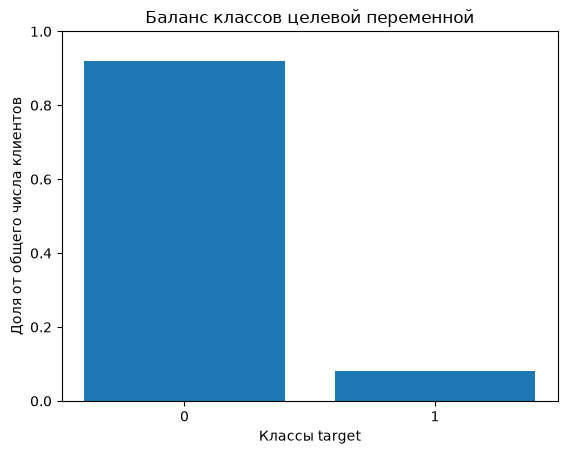

In [79]:
target = df.groupby('TARGET')['TARGET'].value_counts() / len(df)
print(target)

plt.title('Баланс классов целевой переменной')
plt.bar(target.index, target)
plt.ylabel('Доля от общего числа клиентов')
plt.ylim(0, 1)
plt.xlabel('Классы target')
plt.xticks([0, 1])
plt.show()

Имеется сильный дисбаланс классов: почти 92% значений 0 и только около 8% со значением 1.

**ВЫВОД ПО БЛОКУ:** необходима стратификация при сплите на train/val/test

### Типы признаков

#### Типы данных в таблице

In [85]:
df.info()

<class 'pandas.DataFrame'>
Index: 307511 entries, 100002 to 456255
Columns: 121 entries, TARGET to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), str(16)
memory usage: 286.2 MB


65 признаков с типом float64, 40 - с int64 и 16 с типом str